<a href="https://colab.research.google.com/github/vencov/FAV_upsidedown/blob/main/TutOEME/EX_MEMR_interactive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Middle Ear Model — Studying the Middle Ear Muscle Reflex (MEMR)

This notebook is a Python/Colab port of a MATLAB implementation of the
**Pascal, Bourgeade, Lagier & Legros (1998)** lumped-element circuit model
of the human middle ear, coupled to an outer-ear-canal transmission-line
section, solved in the frequency domain by the **method of loop currents**.

The original MATLAB code solved the circuit *symbolically* (`syms`, `solve`)
and then substituted numeric impedance values. Here the exact same 3×3
linear system is solved *numerically*, one small linear system per
frequency point, using `numpy.linalg.solve` (vectorized across all
frequencies at once). The circuit topology, element values and equations
are otherwise unchanged from the original.

## What is the middle ear muscle reflex (MEMR)?

At high sound levels (roughly **80–120 dB SPL**), the **stapedius muscle**
contracts reflexively, stiffening the ossicular chain (via the
stapes/annular-ligament complex). This is thought to help protect the
inner ear from loud, sustained sounds, mainly by **attenuating
low-frequency energy** transmitted to the cochlea.

In this model the reflex is controlled by a single parameter, **`Lt`**
(the sound pressure level at the eardrum, in dB SPL, that drives the
reflex). Below 80 dB SPL the reflex is inactive; from 80–120 dB SPL an
empirical stiffness term (`Cst`, entering the circuit as a reactance
`XCst` in series with the stapes/annular-ligament branch `Zx`) increases
with level, stiffening the chain.

**Your job in this notebook:** use the sliders below to activate the
reflex, and observe how it changes:
- the **input impedance** of the middle ear,
- the **middle-ear transfer function** (eardrum → cochlear vestibule
  pressure), in both frequency and time domain.


## 1. Setup

In [2]:
# Colab already ships numpy/scipy/matplotlib/ipywidgets, but this is
# harmless if they're already installed.
!pip install -q ipywidgets numpy scipy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Checkbox, VBox
import ipywidgets as widgets

j = 1j
plt.rcParams['figure.dpi'] = 100


## 2. The middle ear circuit model

This function builds every branch impedance of the circuit exactly as in
the original MATLAB script (ear canal, middle-ear cavities, eardrum
losses, eardrum–malleus–incus complex, incudo-stapedial joint, cochlea,
and the stapes/annular-ligament/vestibular-volume branch that carries the
acoustic-reflex reactance `XCst`), assembles the 3×3 loop-current linear
system, and solves it **for every frequency at once**.

**Reflex parameters exposed as function arguments** (these are what the
sliders below will control):
- `Lt` — eardrum SPL (dB) driving the acoustic reflex. `Lt < 80` → reflex
  off. `80 ≤ Lt ≤ 120` → reflex engaged, stiffness grows with level.
- `Rla` — annular-ligament resistance (damping in the stapes/annular
  ligament complex). The literature default is 26.58 (Ω-equivalent,
  model units), but there is real inter-individual variability here —
  moving this slider lets you explore how a "stiffer/floppier" reflex
  pathway changes the result.


In [3]:
def build_model(Lt=0.0, Rla=26.5778, freq=None):
    '''
    Solve the Pascal et al. (1998) middle-ear circuit (loop-current method)
    across frequency.

    Parameters
    ----------
    Lt   : float, eardrum SPL (dB) driving the middle-ear (acoustic) reflex.
           Reflex is inactive for Lt < 80 dB SPL.
    Rla  : float, annular-ligament resistance (reflex-pathway damping).
    freq : optional array of frequencies (Hz). Defaults to 50-10000 Hz, 1 Hz steps
           (same range as the original MATLAB script: freq = 50:1e4).

    Returns
    -------
    dict with freq, Zin (input impedance), Hme (ME transfer function,
    area-ratio corrected pc/pt), ec_tf (ear-canal transfer function pt/pin),
    stapes_v_over_pt (stapes volume-velocity / eardrum pressure).
    '''
    if freq is None:
        freq = np.arange(50, 10001, 1.0)  # Hz, matches MATLAB's 50:1e4
    omega = 2*np.pi*freq
    v0 = 0.2          # arbitrary current-source amplitude (model is linear,
    I0f = v0           # transfer functions are independent of this value)

    EffectiveEardrumArea = 55.0   # mm^2
    FootplateArea = 3.2           # mm^2
    AreaRatio = EffectiveEardrumArea / FootplateArea

    # ---------------- outer ear canal (CGS units) ----------------
    EClength = 1.5          # cm
    Rd = 0.4                # cm, canal radius
    Sd = np.pi*Rd**2        # cm^2
    rho0 = 0.00118          # g/cm^3
    mu = 1.83e-4
    c0 = 34590.0             # cm/s
    lambda_h = 24.4e-3*1e5
    Cp = 1010*1e4
    gamma = 1.4

    R11 = 4*np.pi*EClength*mu
    L12 = rho0*np.pi*Rd**2*EClength
    Z12 = R11 + j*omega*L12/Sd**2

    C31 = EClength*gamma/(rho0*c0**2*np.pi*Rd**2)
    R321 = 8*np.pi*lambda_h/((omega/c0)**2*EClength*Cp*(gamma-1))
    L322 = (2*np.pi*Rd**2*rho0)/((omega/c0)**2*EClength*(gamma-1))
    Z3 = (1.0/(j*omega*C31 + 1.0/(R321 + j*omega*L322)))/Sd**2

    # ---------------- middle-ear cavities ----------------
    XLa = omega*12e-3
    XCcp = -1.0/(omega*3.6e-6)
    Ra = 20.0
    Rcm = 420.0
    XCcm = -1.0/(omega*0.35e-6)
    Zme = (1.0/Rcm + 1.0/(j*XCcm) + 1.0/(Ra + j*XCcp + j*XLa))**(-1)

    # ---------------- eardrum losses ----------------
    Rti1 = 200.0
    XCti1 = -1.0/(omega*0.5e-6)
    XCti2 = -1.0/(omega*0.3e-6)
    Rti2 = 105.0
    Rti3 = 12500.0
    XLti = omega*15e-3
    XCti3 = -1.0/(omega*0.2e-6)
    Zti = Rti1 + j*XCti1 + (1.0/(Rti2+j*XCti2) + 1.0/(j*XLti))**(-1) \
          + (1.0/Rti3 + 1.0/(j*XCti3))**(-1)

    # ---------------- eardrum-malleus-incus ----------------
    XCte = -1.0/(omega*1.4e-6)
    XLte = omega*40e-3
    Rte = 65.0
    Zte = j*XCte + j*XLte + Rte

    # ---------------- incudo-stapedial joint ----------------
    XCis = -1.0/(omega*0.03e-6)
    Ris = 170.0
    Zis = j*XCis + Ris

    # ---------------- cochlea (lumped input impedance) ----------------
    Rco = 1211.0
    Rh = 850.0                # helicotrema
    XLh = omega*150e-3
    Zz = (1.0/Rco + 1.0/(Rh + j*XLh))**(-1)

    # ---------------- stapes / acoustic (MEMR) reflex / annular ligament / vestibular volume ----------------
    if Lt < 80:
        XCst = np.zeros_like(omega)     # reflex not engaged
    else:
        ptCst = 10**(Lt/20)*2e-5        # Pa, eardrum pressure for this SPL
        x = 20*np.log10(ptCst/0.2)      # == Lt - 80
        denom = 1675*x**2 + 33000*x
        if abs(denom) < 1e-9:
            denom = 1e-9
        Cst = 1.0/denom
        XCst = -1.0/(omega*Cst)

    XCla = -1.0/(omega*0.4380e-6)
    XLs = omega*8e-3
    XLv = omega*21e-3
    Zx = j*XLs + j*XCst + Rla + j*XCla + j*XLv

    # ---------------- loop-current equations, solved per frequency ----------------
    # eqn1: Z3*(I1-I0) + (Z12+Zme)*I1 + Zti*(I1-I2) = 0
    # eqn2: Zti*(I2-I1) + Zte*I2 + Zis*(I2-I3)       = 0
    # eqn3: Zis*(I3-I2) + Zx*I3 + Zz*I3              = 0
    Nf = len(freq)
    A = np.zeros((Nf, 3, 3), dtype=complex)
    b = np.zeros((Nf, 3, 1), dtype=complex)

    A[:, 0, 0] = Z3 + Z12 + Zme + Zti
    A[:, 0, 1] = -Zti
    A[:, 1, 0] = -Zti
    A[:, 1, 1] = Zti + Zte + Zis
    A[:, 1, 2] = -Zis
    A[:, 2, 1] = -Zis
    A[:, 2, 2] = Zis + Zx + Zz
    b[:, 0, 0] = Z3*I0f

    I = np.linalg.solve(A, b)[:, :, 0]
    I1f, I2f, I3f = I[:, 0], I[:, 1], I[:, 2]

    pt = -(Z12*I1f + Z3*(I1f - I0f))     # pressure at the eardrum
    pin = Z12*I0f + Z3*(I0f - I1f)        # pressure at the probe / input
    Zin = pt/I1f                          # input impedance of the ME circuit
    PcPt = Zz*I3f/pt                      # vestibular pressure / eardrum pressure
    Hme = AreaRatio*PcPt                  # ME transfer function (area-ratio corrected)
    stapes_v_over_pt = I3f/pt             # stapes volume velocity / eardrum pressure
    ec_tf = pt/pin                        # ear-canal transfer function

    return dict(freq=freq, Zin=Zin, Hme=Hme, ec_tf=ec_tf,
                stapes_v_over_pt=stapes_v_over_pt, pt=pt, pin=pin)


## 3. From frequency response to time response

To *see* the reflex's effect in the time domain (e.g. on a click / impulse
response), we take the frequency-domain transfer function `Hme(f)`,
extend it down to 0 Hz (flat extrapolation below 50 Hz, where the model
isn't defined) and mirror it for conjugate symmetry, then take an
inverse FFT to get a real impulse response.


In [4]:
def impulse_response(freq, Hf, fs=None):
    '''
    Build a real time-domain impulse response from a one-sided complex
    frequency response Hf(freq) (uniformly spaced, e.g. 1 Hz steps).
    '''
    df = freq[1] - freq[0]
    fmax = freq[-1]
    if fs is None:
        fs = 2*fmax  # sample rate such that Nyquist == fmax
    n_half = int(round(fmax/df)) + 1
    H_full = np.empty(n_half, dtype=complex)
    n_missing = int(round(freq[0]/df))
    H_full[n_missing:n_missing+len(Hf)] = Hf
    if n_missing > 0:
        H_full[:n_missing] = Hf[0]     # flat extrapolation down to 0 Hz

    Nfft = 2*(n_half - 1)
    S = np.zeros(Nfft, dtype=complex)
    S[:n_half] = H_full
    S[n_half:] = np.conj(H_full[1:-1][::-1])
    h = np.fft.ifft(S).real
    t = np.arange(Nfft)/fs
    return t, h


## 4. Baseline response (reflex off)

A quick static look at the model with the reflex inactive (`Lt = 0`),
before we make it interactive.


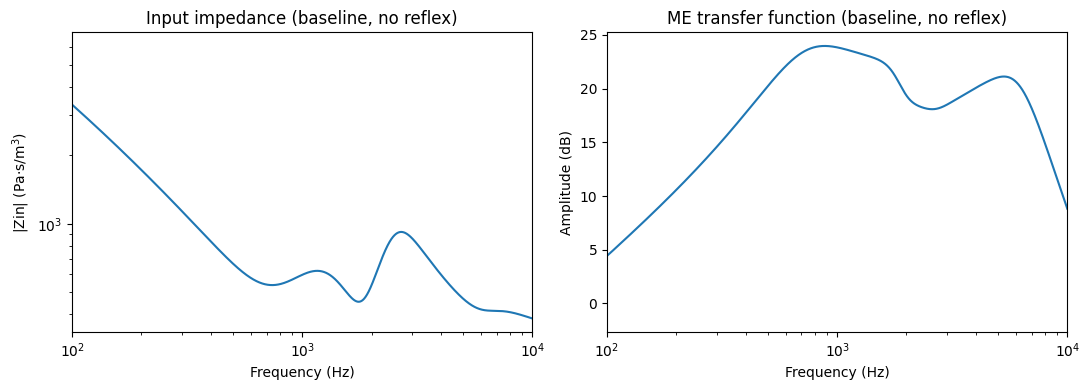

In [5]:
baseline = build_model(Lt=0.0)
f = baseline['freq']

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].loglog(f, np.abs(baseline['Zin']))
axs[0].set_xlim(100, 1e4)
axs[0].set_xlabel('Frequency (Hz)'); axs[0].set_ylabel('|Zin| (Pa·s/m$^3$)')
axs[0].set_title('Input impedance (baseline, no reflex)')

axs[1].semilogx(f, 20*np.log10(np.abs(baseline['Hme'])))
axs[1].set_xlim(100, 1e4)
axs[1].set_xlabel('Frequency (Hz)'); axs[1].set_ylabel('Amplitude (dB)')
axs[1].set_title('ME transfer function (baseline, no reflex)')
plt.tight_layout()
plt.show()


## 5. Interactive exploration — turn the reflex on

Use the sliders to set the eardrum SPL driving the reflex (`Lt`) and the
annular-ligament resistance (`Rla`). Tick the checkbox to overlay the
**no-reflex baseline** (`Lt = 0`) for direct comparison.

- **Top-left:** ME transfer function amplitude (the main "gain" curve —
  this is where MEMR attenuation, mostly at low frequencies, is most
  visible).
- **Top-right:** input impedance magnitude.
- **Bottom-left:** ME transfer function phase.
- **Bottom-right:** time-domain impulse response (first few ms) — shows
  how the reflex changes the transient response of the middle ear.

The text above the figure reports the reflex-induced attenuation (in dB)
at 500 Hz and 4000 Hz, so you can compare low- vs. high-frequency effects
quantitatively.


In [6]:
def plot_memr(Lt=100.0, Rla=26.5778, compare_baseline=True):
    reflex = build_model(Lt=Lt, Rla=Rla)
    f = reflex['freq']

    if compare_baseline:
        baseline = build_model(Lt=0.0, Rla=26.5778)

    fig, axs = plt.subplots(2, 2, figsize=(11, 8))

    # --- ME transfer function amplitude ---
    ax = axs[0, 0]
    if compare_baseline:
        ax.semilogx(f, 20*np.log10(np.abs(baseline['Hme'])), '--', color='gray',
                    label='No reflex (Lt=0)')
    ax.semilogx(f, 20*np.log10(np.abs(reflex['Hme'])), color='C0',
                label=f'Reflex, Lt={Lt:.0f} dB')
    ax.set_xlim(100, 1e4)
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Amplitude (dB)')
    ax.set_title('Middle ear transfer function')
    ax.legend(loc='lower right'); ax.grid(True, which='both', alpha=0.3)

    # --- Input impedance magnitude ---
    ax = axs[0, 1]
    if compare_baseline:
        ax.loglog(f, np.abs(baseline['Zin']), '--', color='gray', label='No reflex')
    ax.loglog(f, np.abs(reflex['Zin']), color='C1', label=f'Lt={Lt:.0f} dB')
    ax.set_xlim(100, 1e4)
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('|Zin| (Pa·s/m$^3$)')
    ax.set_title('Input impedance')
    ax.legend(loc='best'); ax.grid(True, which='both', alpha=0.3)

    # --- ME transfer function phase ---
    ax = axs[1, 0]
    if compare_baseline:
        ax.semilogx(f, np.unwrap(np.angle(baseline['Hme']))*180/np.pi, '--',
                    color='gray', label='No reflex')
    ax.semilogx(f, np.unwrap(np.angle(reflex['Hme']))*180/np.pi, color='C0',
                label=f'Lt={Lt:.0f} dB')
    ax.set_xlim(100, 1e4)
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Phase (deg.)')
    ax.set_title('Middle ear transfer function — phase')
    ax.legend(loc='best'); ax.grid(True, which='both', alpha=0.3)

    # --- Time domain impulse response ---
    ax = axs[1, 1]
    t_r, h_r = impulse_response(f, reflex['Hme'])
    win = t_r < 5e-3  # first 5 ms
    if compare_baseline:
        t_b, h_b = impulse_response(f, baseline['Hme'])
        ax.plot(t_b[win]*1e3, h_b[win], '--', color='gray', label='No reflex')
    ax.plot(t_r[win]*1e3, h_r[win], color='C2', label=f'Lt={Lt:.0f} dB')
    ax.set_xlabel('Time (ms)'); ax.set_ylabel('Amplitude (a.u.)')
    ax.set_title('Impulse response (click stimulus)')
    ax.legend(loc='best'); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # quantitative readout
    def db_at(freq_target, out):
        idx = np.argmin(np.abs(f - freq_target))
        return 20*np.log10(np.abs(out['Hme'][idx]))

    if compare_baseline:
        for f0 in (500, 4000):
            atten = db_at(f0, baseline) - db_at(f0, reflex)
            print(f"Reflex-induced attenuation at {f0:5d} Hz: {atten:5.2f} dB")
    else:
        print("Tick 'compare_baseline' to see the reflex-induced attenuation in dB.")


interact(
    plot_memr,
    Lt=FloatSlider(value=100, min=0, max=120, step=1, description='Lt (dB SPL)',
                    continuous_update=False, style={'description_width': 'initial'}),
    Rla=FloatSlider(value=26.5778, min=5, max=100, step=1,
                     description='Rla (annular lig. R)',
                     continuous_update=False, style={'description_width': 'initial'}),
    compare_baseline=Checkbox(value=True, description='Compare with no-reflex baseline'),
);


interactive(children=(FloatSlider(value=100.0, continuous_update=False, description='Lt (dB SPL)', max=120.0, …

## 6. Questions for study / discussion

1. Below 80 dB SPL the reflex is inactive by definition in this model.
   What happens to the curves as you cross the 80 dB threshold — is the
   onset abrupt or gradual as `Lt` increases further?
2. At which frequencies is the reflex-induced attenuation of the ME
   transfer function largest? Does this match what you know about the
   physiological role of the MEMR (protection against low-frequency,
   high-level sound)?
3. How does the input impedance change with increasing `Lt`? Physically,
   why should stiffening the ossicular chain change the impedance seen
   from the ear canal?
4. Try changing `Rla` (annular-ligament resistance) at a fixed `Lt`. Does
   more damping mainly change the *amplitude* of the transfer function,
   the *sharpness* of any features, or both?
5. Look at the impulse response. Does engaging the reflex mainly change
   the amplitude of the response, its timing, or the amount of
   "ringing" (decay time)? Can you connect this to the impedance/transfer
   function changes you saw in the frequency domain?


## 7. Optional extension — comparing to experimental data / alternate cochlear models

The original MATLAB script additionally overlaid:
- experimental human middle-ear data from **Puria et al. (1993)**, and
- two alternative cochlear input-impedance models (`ZcModel01.mat`,
  `ZcModel02.mat`) produced by a separate cochlear model, used **in place
  of** the simple lumped cochlear impedance `Zz` used above.

These come from `.mat` data files that were not part of the code you
shared, so they aren't loaded here by default. If you have those files,
you can upload them in Colab (folder icon on the left → upload, or run
the cell below) and load them with `scipy.io.loadmat`; the cell is set up
so it simply reports what's missing rather than erroring out.


In [ ]:
from scipy.io import loadmat
import os

needed_files = ['ZcModel01.mat', 'ZcModel02.mat',
                 'MEPuriaImpAmpl.mat', 'MEPuriaImpPhase.mat',
                 'MEPuriaAmpl.mat', 'MEPuriaPhase.mat']

# Uncomment to upload interactively in Colab:
# from google.colab import files
# uploaded = files.upload()

missing = [fn for fn in needed_files if not os.path.exists(fn)]
if missing:
    print("Optional data files not found (skipping extended comparison):")
    for fn in missing:
        print("  -", fn)
else:
    Zc1 = loadmat('ZcModel01.mat')
    Zc2 = loadmat('ZcModel02.mat')
    print("Loaded alternate cochlear-impedance models:", list(Zc1.keys()), list(Zc2.keys()))
    # From here you could interp1-equivalent (np.interp / scipy.interpolate)
    # Zc1['Zc'] onto the model's freq axis and substitute it for Zz in
    # build_model(), mirroring the MATLAB ZcModel1/ZcModel2 branches.
